---
**Biophysics:** Polymer Folding

---

In [1]:
# %% Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time  # Adding timer using a clock

In [2]:
start_time = time.process_time()
loop_time = start_time  # Start time for loop timer

# %% Constants and Variables
n = 100  # Number of beads in a polymer
pol = 10  # Number of polymers
max_attempts = 100  # Maximum attempts to place a new bead
epsilon = 0.25  # Depth of the potential well
sigma = 0.8  # Finite distance at which the inter-particle potential is zero
T = 1.0  # Temperature
size = 0

# %% Allocation
pos = np.zeros((pol, n, 2), dtype=float)  # Positions of the atoms for every polymer


In [3]:
# %% define functions
def lennard_jones_potential(r):
    """
    Calculate the Lennard-Jones potential.
    :param r: Distance between two particles
    :return: Lennard-Jones potential
    """
    return 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

def calculate_total_energy(positions, atom):
    """
    Calculate the total energy of the polymer up to a given atom.
    :param positions: Positions of the atoms in the polymer
    :param atom: Index of the last atom to consider
    :return: Total energy
    """
    energy = 0.0
    for i in range(atom):
        for j in range(i + 1, atom + 1):
            r = np.linalg.norm(positions[i] - positions[j])
            if r != 0:
                energy += lennard_jones_potential(r)
    return energy

def metropolis_criterion(old_energy, new_energy):
    """
    Decide whether to accept the new state based on the Metropolis criterion.
    :param old_energy: Energy of the old state
    :param new_energy: Energy of the new state
    :return: True if the new state is accepted, False otherwise
    """
    if new_energy < old_energy:
        return True
    else:
        delta_energy = new_energy - old_energy
        acceptance_probability = np.exp(-delta_energy / T)
        return np.random.rand() < acceptance_probability

def attempt_add_bead(atom, position, fixed_distance=1.0):
    """
    Attempts to add a new bead to a polymer with a fixed distance from the previous bead and self-avoidance.
    :param atom: The index of the new bead to be added
    :param position: Current positions of the polymer
    :param fixed_distance: Fixed distance between consecutive beads
    :return: New position of the bead, None if no valid position is found
    """
    old_energy = calculate_total_energy(position, atom - 1)
    for _ in range(max_attempts):
        angle = np.random.uniform(0, 2 * np.pi)
        new_position = position[atom - 1] + fixed_distance * np.array([np.cos(angle), np.sin(angle)])

        # Check for self-avoidance
        if not np.any(np.all(np.isclose(position[:atom], new_position), axis=1)):
            position[atom] = new_position
            new_energy = calculate_total_energy(position, atom)
            if metropolis_criterion(old_energy, new_energy):
                return new_position
    return None


def calculate_end_to_end_dist(positions):
    return np.linalg.norm(positions[:, -1] - positions[:, 0], axis=1)

def calculate_radius_of_gyration(positions):
    center_of_mass = np.mean(positions, axis=1)
    squared_distance = np.sum((positions - center_of_mass[:, np.newaxis, :]) ** 2, axis=2)
    return np.sqrt(np.mean(squared_distance, axis=1))


In [4]:
# %% Monte Carlo Simulation
for polymer in range(pol):
    for atom in range(1, n):
        new_pos = attempt_add_bead(atom, pos[polymer])
        if new_pos is None:
            size = atom
            break  # Stop growing this polymer if no valid position is found
    print("Pol %4.0f Made of %4.0f beads in %6.4f seconds" % (polymer, size, time.process_time() - start_time))


Pol    0 Made of   98 beads in 8.3057 seconds
Pol    1 Made of   63 beads in 10.7910 seconds
Pol    2 Made of   63 beads in 14.3822 seconds
Pol    3 Made of   63 beads in 16.6712 seconds
Pol    4 Made of   39 beads in 17.1771 seconds
Pol    5 Made of   39 beads in 20.5175 seconds
Pol    6 Made of   39 beads in 24.5224 seconds
Pol    7 Made of   39 beads in 28.0580 seconds
Pol    8 Made of   44 beads in 29.7612 seconds
Pol    9 Made of   44 beads in 32.9063 seconds


In [5]:
# %% Analysis
end_to_end_dist = calculate_end_to_end_dist(pos)
mean_end_to_end_dist = np.mean(end_to_end_dist)
std_end_to_end_dist = np.std(end_to_end_dist)

radius_of_gyration = calculate_radius_of_gyration(pos)
mean_radius_of_gyration = np.mean(radius_of_gyration)
std_radius_of_gyration = np.std(radius_of_gyration)

print(f"Mean end-to-end distance: {mean_end_to_end_dist:.2f}")
print(f"Standard deviation of end-to-end distance: {std_end_to_end_dist:.2f}")
print(f"Mean radius of gyration: {mean_radius_of_gyration:.2f}")
print(f"Standard deviation of radius of gyration: {std_radius_of_gyration:.2f}")

Mean end-to-end distance: 13.68
Standard deviation of end-to-end distance: 12.97
Mean radius of gyration: 6.43
Standard deviation of radius of gyration: 2.56


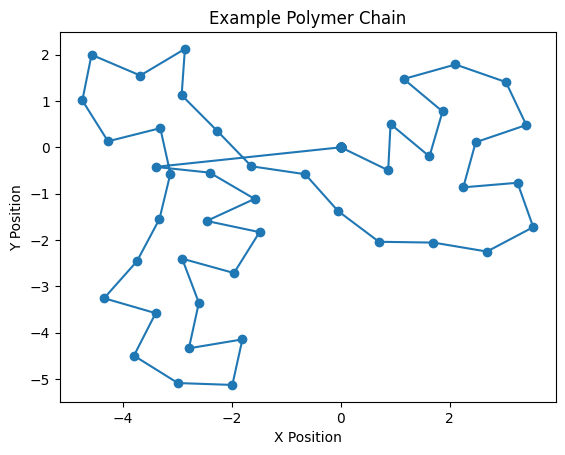

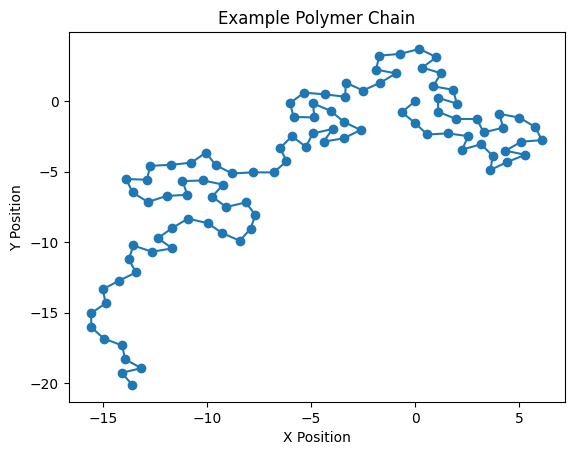

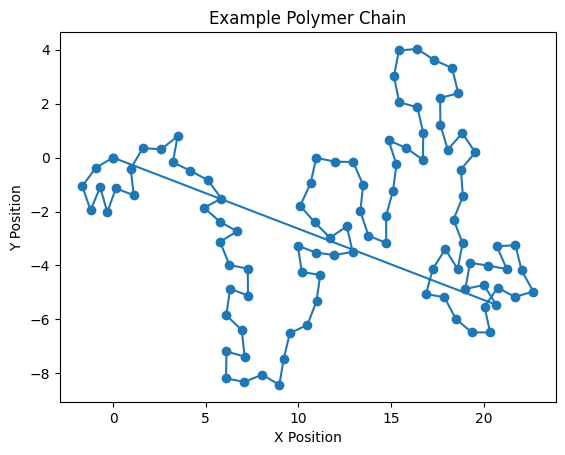

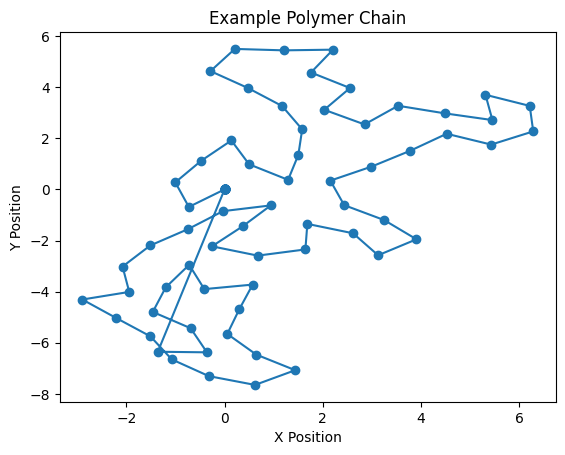

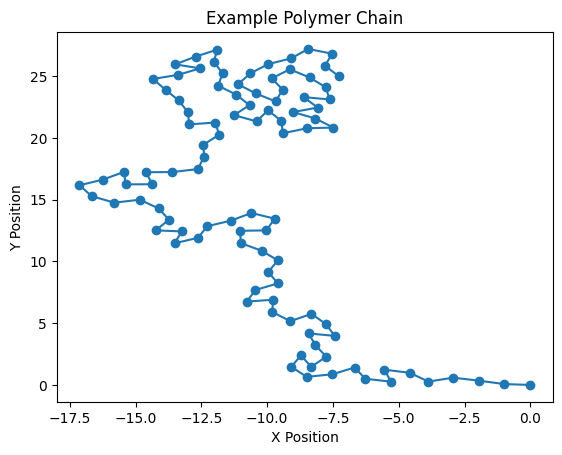

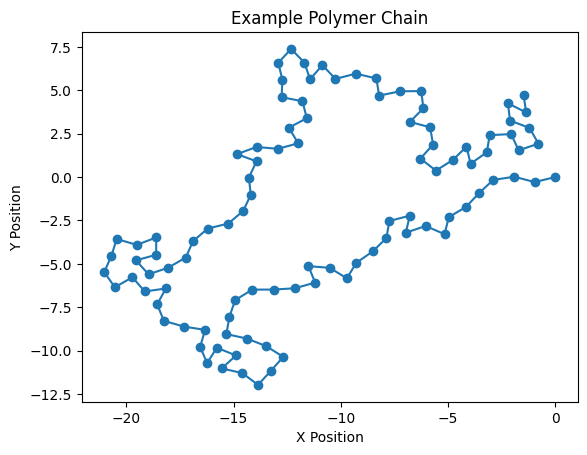

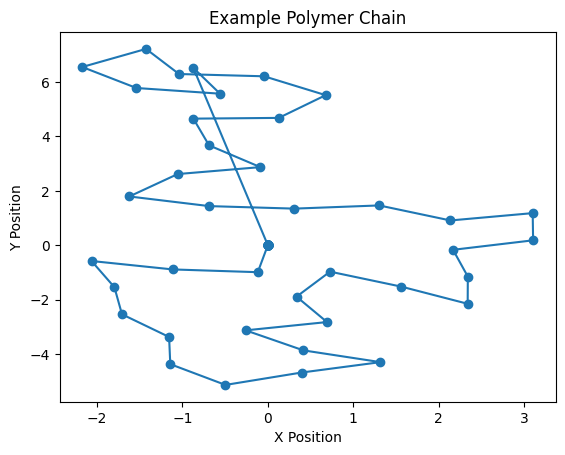

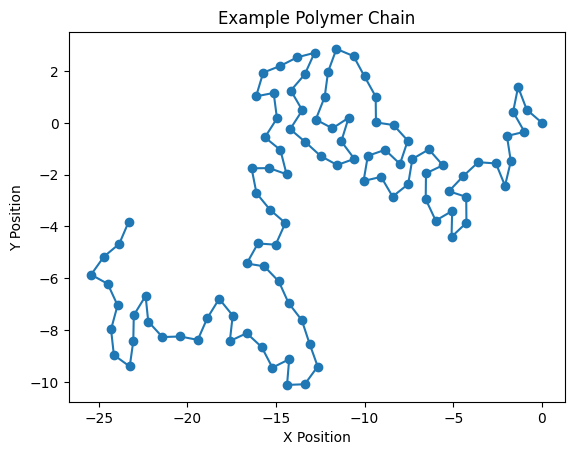

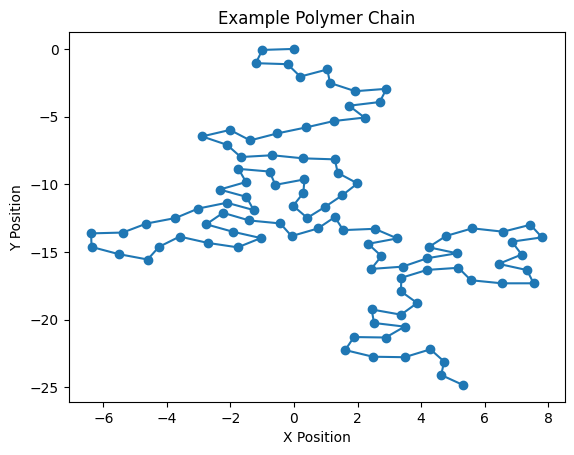

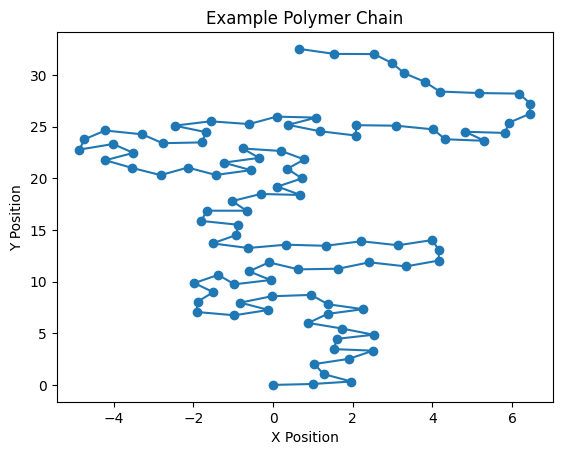

In [6]:
# %% Plotting an example polymer
for i in range(10):
    plt.figure(i+2)
    plt.plot(pos[i-2, :, 0], pos[i-2, :, 1], '-o')
    plt.title("Example Polymer Chain")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.show(block=False)
plt.show()